In [42]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import bilby

In [ ]:
BASE_PATH   = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns'
BNS_PATH    = BASE_PATH + '/bns/networks/'
NSBH_PATH   = BASE_PATH + '/bhns/networks/'
OUTPUT_FILE = BASE_PATH + 'bns_nsbh_fisher_gaussians.h5'

import sys

SAMPLER_DIR = (BASE_PATH + '/CE_STM_CBC/pop_models/stellar_mass/'
               'injection_sampler_v2')
EOS_DIR = SAMPLER_DIR + '/sfho_compose_files'

# drop any copy imported from another sampler version earlier in this kernel
sys.modules.pop('generate_tidal_params_correct', None)
sys.path.insert(0, SAMPLER_DIR)

import generate_tidal_params_correct as gtp
from generate_tidal_params_correct import LambdaCalculator, MSUN_GEOM, TOV_RTOL

assert gtp.__file__.startswith(SAMPLER_DIR), f'wrong module: {gtp.__file__}'
print(f'module: {gtp.__file__}')

# 1000 TOV solves at rtol=1e-6, takes a few minutes; build once and reuse
calc = LambdaCalculator(EOS_DIR, method='interp', mmin=1.0)
print(f'TOV max mass: {calc.eos_max_mass:.4f} Msun')
print(f'Lambda(1.4):   {calc.get_lambda(1.4):.2f}')

In [30]:
path = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/CE_STM_CBC/pop_models/stellar_mass/injection_sampler_v3_z_0.5_10_years/pop_m_FP4_spin_NS_fref_5.0_z_MD_lmr_130_BNS_29K_samples_v3_z_0.5_10_years.h5'
file = h5.File(path)

In [31]:
lam1 = file['lambda_1']
lam2 = file['lambda_2']
mass1 = file['mass_1_source']
mass2 = file['mass_2_source']

In [32]:
# Check if any value is practically zero
l1_zero = np.any(np.isclose(lam1, 0, atol=1e-10))
l2_zero = np.any(np.isclose(lam2, 0, atol=1e-10))
print(l1_zero, l2_zero)

False False


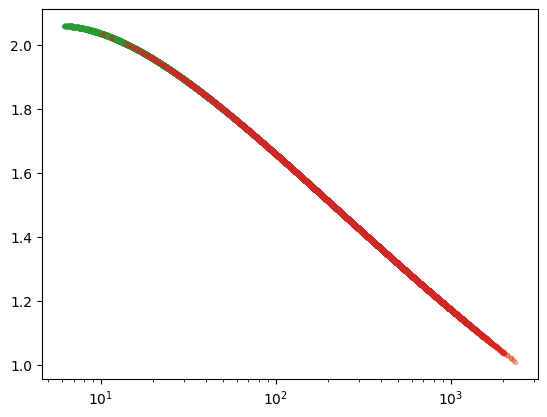

In [34]:
plt.scatter(lam1, mass1, s=10, alpha=0.2)
plt.scatter(lam2, mass2, s=10, alpha=0.2)
plt.scatter(calc.get_lambda(mass1[:]), mass1, s=10, alpha=0.2)
plt.scatter(calc.get_lambda(mass2[:]), mass2, s=10, alpha=0.2)
plt.xscale('log')

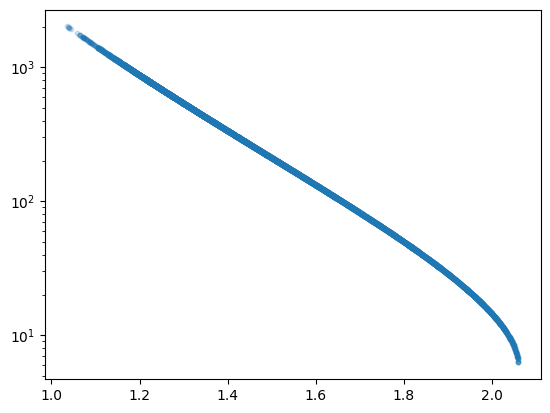

In [48]:
plt.scatter(mass2, calc.get_lambda(mass2[:]), s=10, alpha=0.2)
plt.yscale('log')

In [43]:
# g/cm^3 -> geometric m^-2, same factor generate_tidal_params_correct uses
GCM3_TO_GEOM = (bilby.utils.gravitational_constant / bilby.utils.speed_of_light**2) * 1e3

def eos_curves(calc, n_grid=400):
    """Build the EOS metadata arrays from a LambdaCalculator instead of the npz."""
    fam = calc.fam

    mass = np.asarray(fam.mass) / MSUN_GEOM
    lam = np.asarray(fam.tidal_deformability)
    radius = np.asarray(fam.radius) / 1e3

    order = np.argsort(mass)
    mass, lam, radius = mass[order], lam[order], radius[order]

    good = np.isfinite(mass) & np.isfinite(lam) & (lam > 0) & (mass >= calc.mmin)
    mass, lam, radius = mass[good], lam[good], radius[good]

    # stop at the cap get_lambda enforces, else the tail comes back as zeros
    mass_top = min(mass[-1], calc.eos_max_mass)

    # dense grid through the same PCHIP interpolant used to assign Lambda1/Lambda2
    mass_grid = np.linspace(calc.mmin, mass_top, n_grid)
    lambda_grid = calc.get_lambda(mass_grid)
    radius_grid = np.interp(mass_grid, mass, radius)

    return {
        'eos_name':     'SFHo',
        'eos_dir':      EOS_DIR,
        'tov_rtol':     TOV_RTOL,
        'mmin_msol':    calc.mmin,
        'M_max_TOV':    float(fam.maximum_mass),
        'M_max_used':   float(calc.eos_max_mass),
        'Lambda_1p4':   float(calc.get_lambda(1.4)),
        'Lambda_max':   float(lambda_grid.max()),
        'R_1p4_km':     float(np.interp(1.4, mass, radius)),
        'mass_msol':    mass_grid,
        'lambda':       lambda_grid,
        'radius_km':    radius_grid,
        'pressure_gcc': np.asarray(fam.eos.pressure) / GCM3_TO_GEOM,
        'edensity_gcc': np.asarray(fam.eos.energy_density) / GCM3_TO_GEOM,
    }

def write_eos_metadata(out, calc):
    """Write the eos_metadata group, replacing the old npz block."""
    eos = eos_curves(calc)
    grp = out.create_group('eos_metadata')

    for key in ['eos_name', 'eos_dir', 'tov_rtol', 'mmin_msol',
                'M_max_TOV', 'M_max_used', 'Lambda_1p4', 'Lambda_max', 'R_1p4_km']:
        grp.attrs[key] = eos[key]

    for key in ['mass_msol', 'lambda', 'radius_km', 'pressure_gcc', 'edensity_gcc']:
        grp.create_dataset(key, data=eos[key])

    return grp

In [44]:
out = eos_curves(calc,n_grid=100)

(1.0, 2.3)

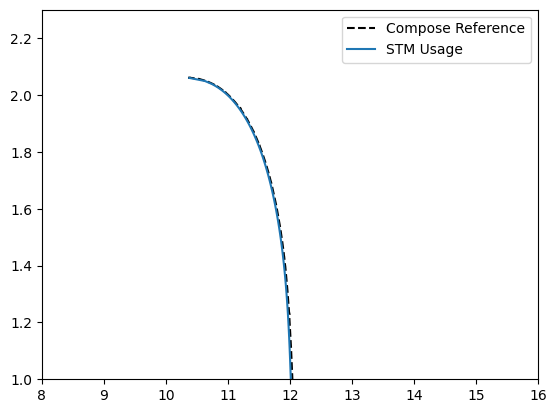

In [52]:
compose_path = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/CE_STM_CBC/pop_models/stellar_mass/injection_sampler_v3_z_0.5_10_years/sfho_compose_files/eos.mr'
compose_file = np.genfromtxt(compose_path)
plt.plot(compose_file[:, 0], compose_file[:, 1], color = 'black', ls = '--', label ='Compose Reference')
plt.plot(out['radius_km'], out['mass_msol'], label = 'STM Usage')
plt.legend()
plt.xlim(8,16)
plt.ylim(1, 2.3)

In [35]:
path = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/CE_STM_CBC/pop_models/stellar_mass/injection_sampler_v3_z_0.5_10_years/pop_m_FP4_spin_AGU_fref_5.0_z_MD_lmr_130_NSBH_12K_samples_v3_z_0.5_10_years.h5'
file = h5.File(path)
lam1 = file['lambda_1']
lam2 = file['lambda_2']
mass1 = file['mass_1_source']
mass2 = file['mass_2_source']

In [38]:
# Check if any value is practically zero
l1_zero = np.any(np.isclose(lam1, 0, atol=1e-10))
l2_zero = np.any(np.isclose(lam2, 0, atol=1e-10))
l1_all_zero = np.allclose(lam1, 0)
print(l1_zero, l2_zero, l1_all_zero)

True False True


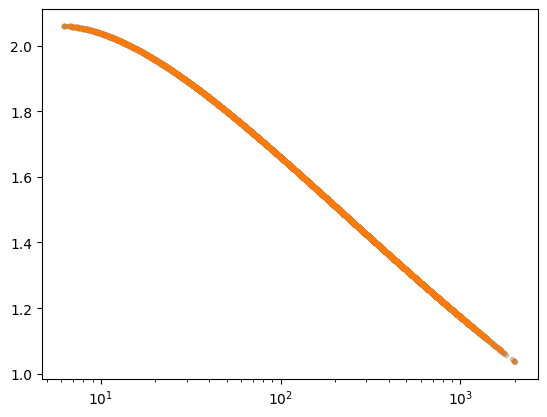

In [40]:
# plt.scatter(lam1, mass1, s=10, alpha=0.2)
plt.scatter(lam2, mass2, s=10, alpha=0.2)
# plt.scatter(calc.get_lambda(mass1[:]), mass1, s=10, alpha=0.2)
plt.scatter(calc.get_lambda(mass2[:]), mass2, s=10, alpha=0.2)
plt.xscale('log')